In [1]:
import os
import re
import json
from dataclasses import dataclass
from typing import List, Dict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [2]:
@dataclass
class Keypoint:
    def __init__(self, id: str, x: float, y: float):
        self.id = id
        self.pixelPosition = (x, y)

@dataclass
class KeypointOnImage:
    def __init__(self, file: str, keypoints: List[Keypoint]):
        self.file = file
        self.keypoints = keypoints


@dataclass
class ModelOutput:
    def __init__(self, model: str, keypointOnImages: List[KeypointOnImage]):
        self.model = model
        self.keypointOnImages = keypointOnImages

@dataclass
class ModelComparison:
    def __init__(self, model: str, keypoint_errors: Dict[str, float]):
        self.model = model
        self.keypoint_errors = keypoint_errors


KEYPOINT_IDS = [
    "nose",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
]

In [3]:
# ----------------- Helpers -----------------
def safe_filename(name: str, max_len: int = 120) -> str:
    # replace illegal filename chars and collapse whitespace
    name = re.sub(r'[<>:"/\\|?*\x00-\x1F]', "_", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name[:max_len]

### Compare outputs of models based on groud truth from RTMO-X

Comparing 13 model outputs against ground truth from RTMO_X on 944 images.
No keypoint nose found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model BlazePose Full
No keypoint left_eye found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model BlazePose Full
No keypoint right_eye found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model BlazePose Full
No keypoint left_ear found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model BlazePose Full
No keypoint right_ear found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model BlazePose Full
No keypoint left_shoulder found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model BlazePose Full
No keypoint right_shoulder found for file 373QGUSuva55Owthq92r_OXCamd6fqUduaV4SZhCL2WvToas1_biceps-curl-db_1_3.jpg in model 

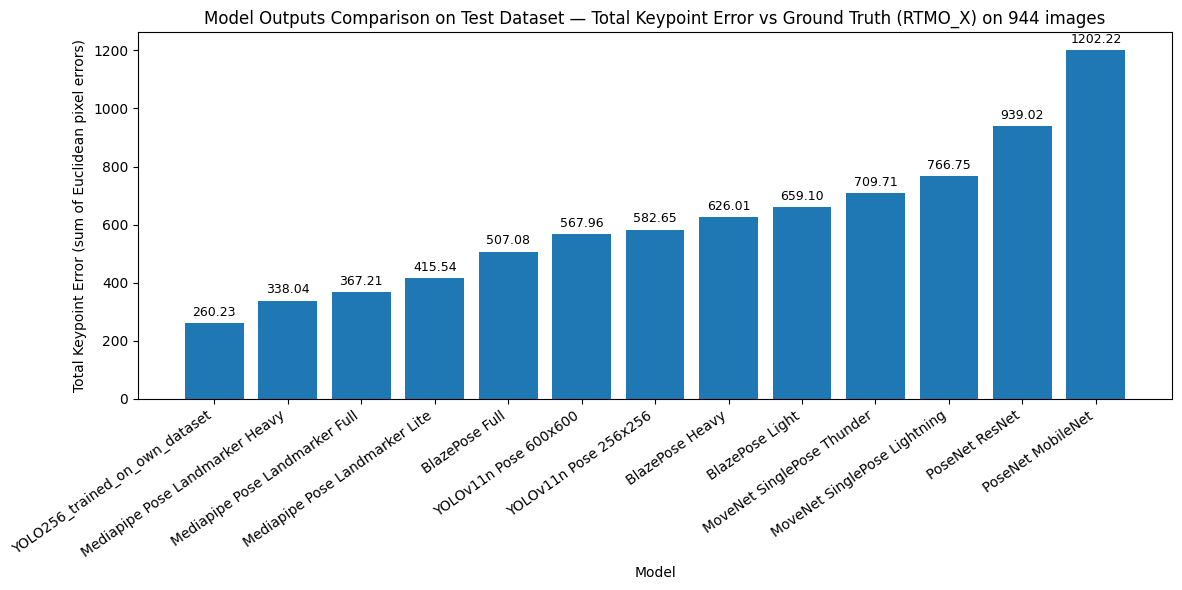

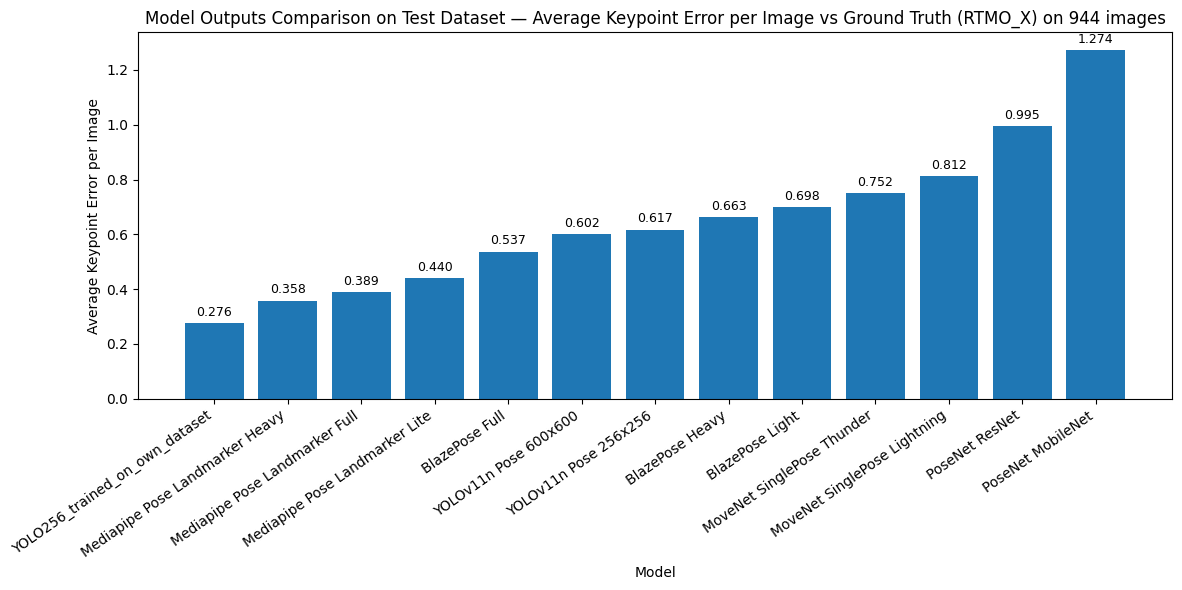

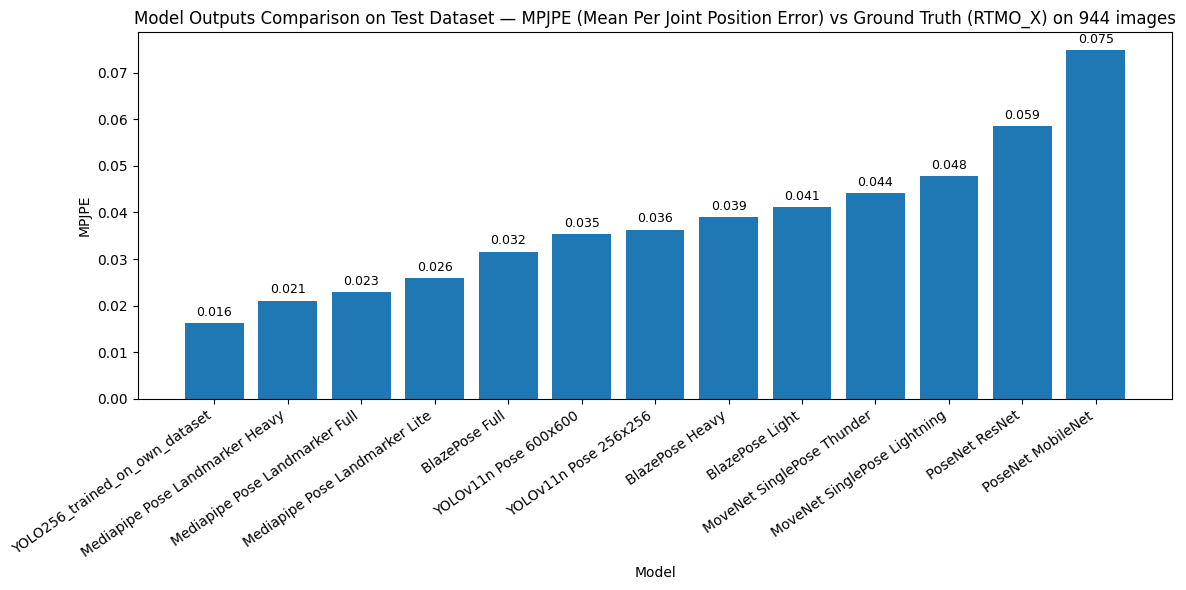

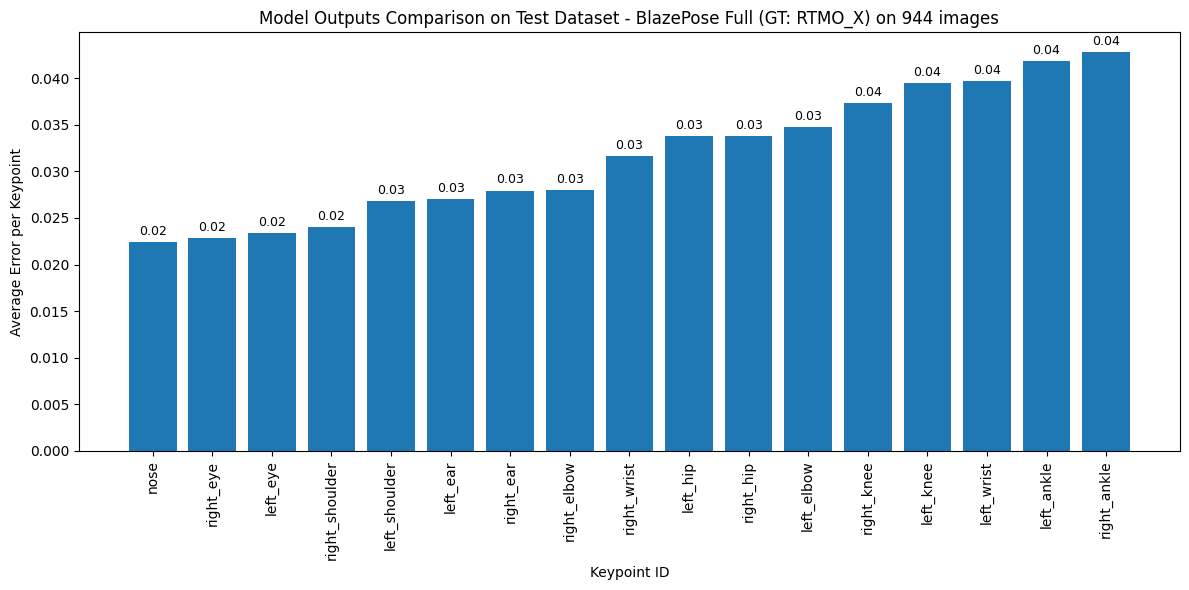

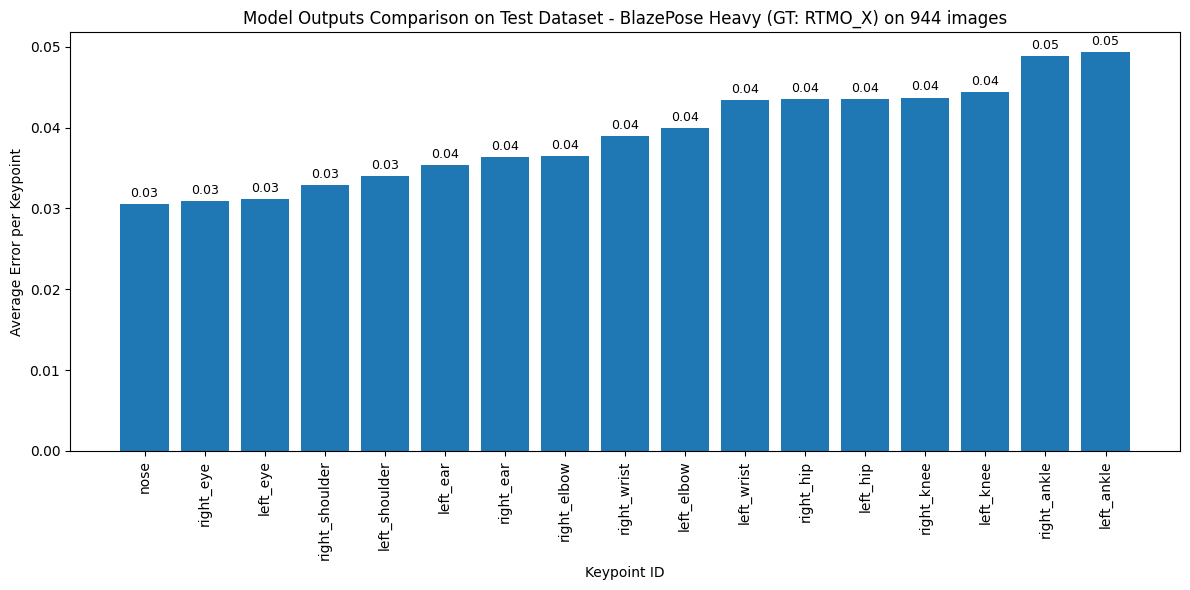

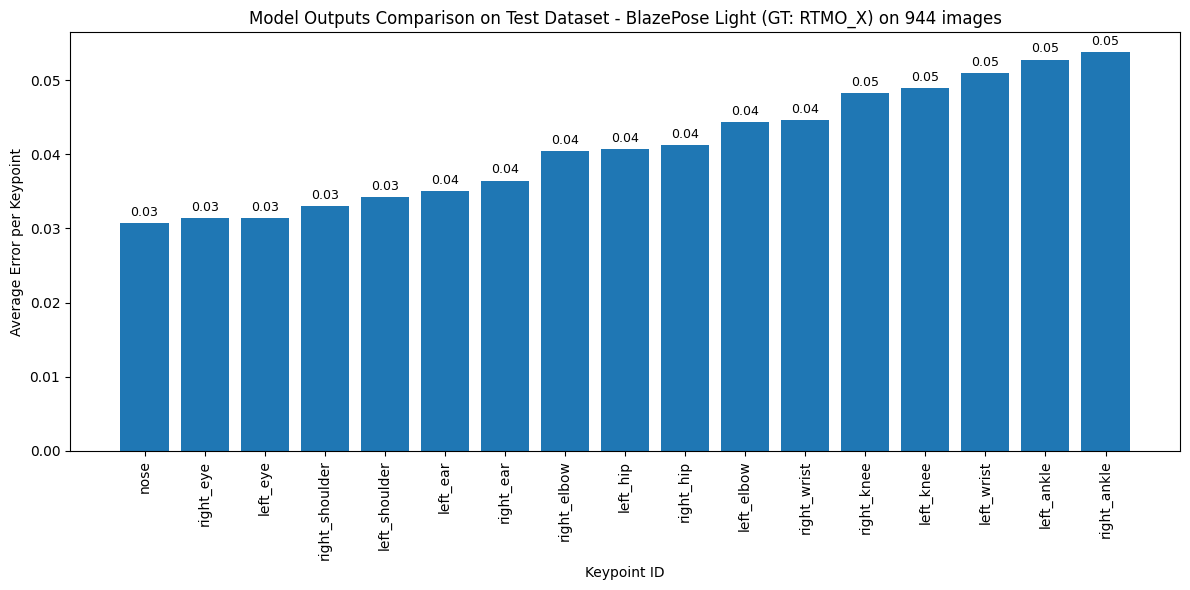

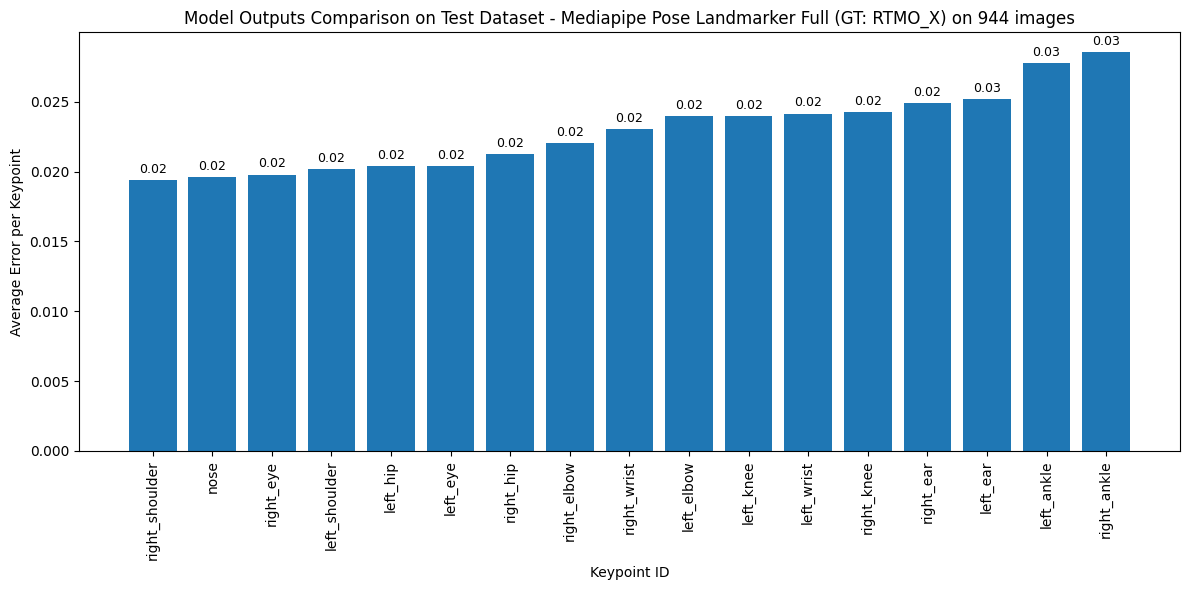

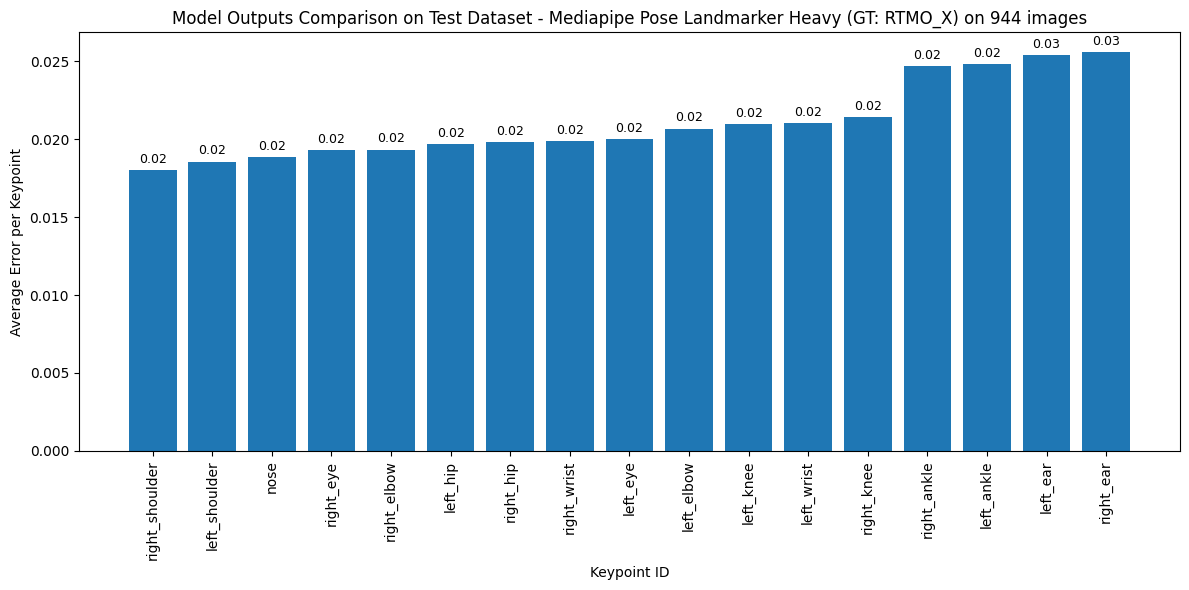

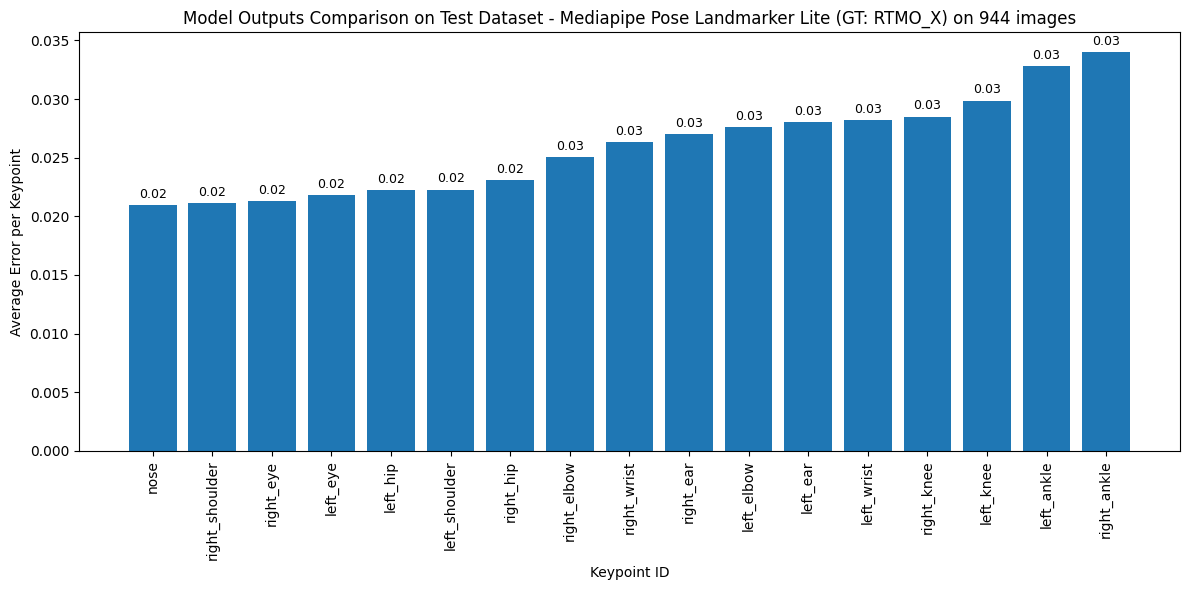

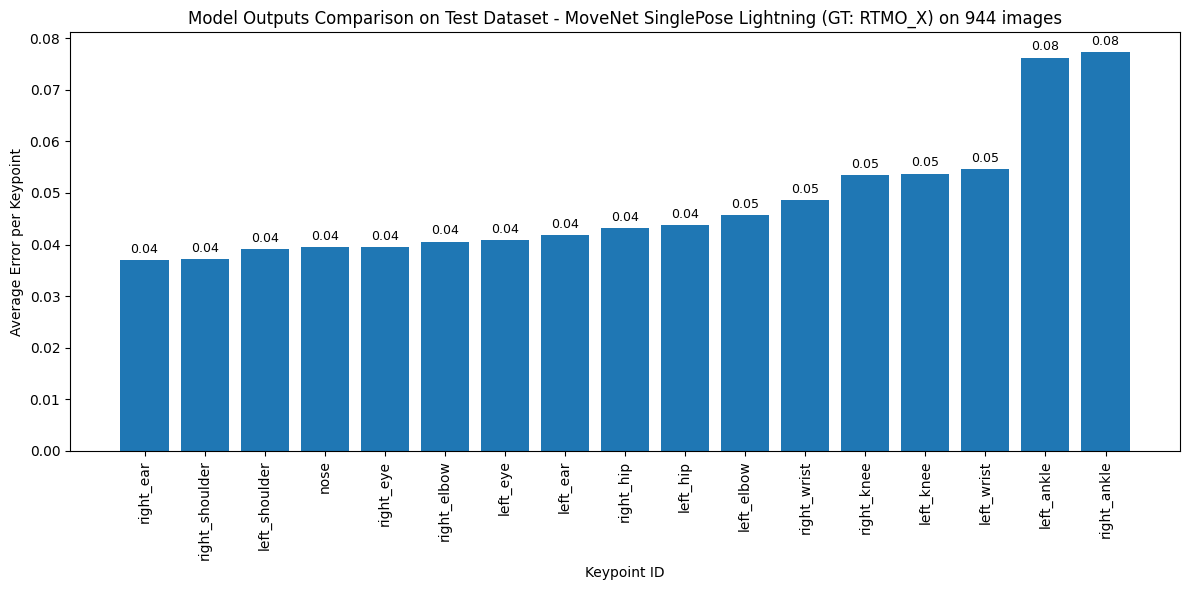

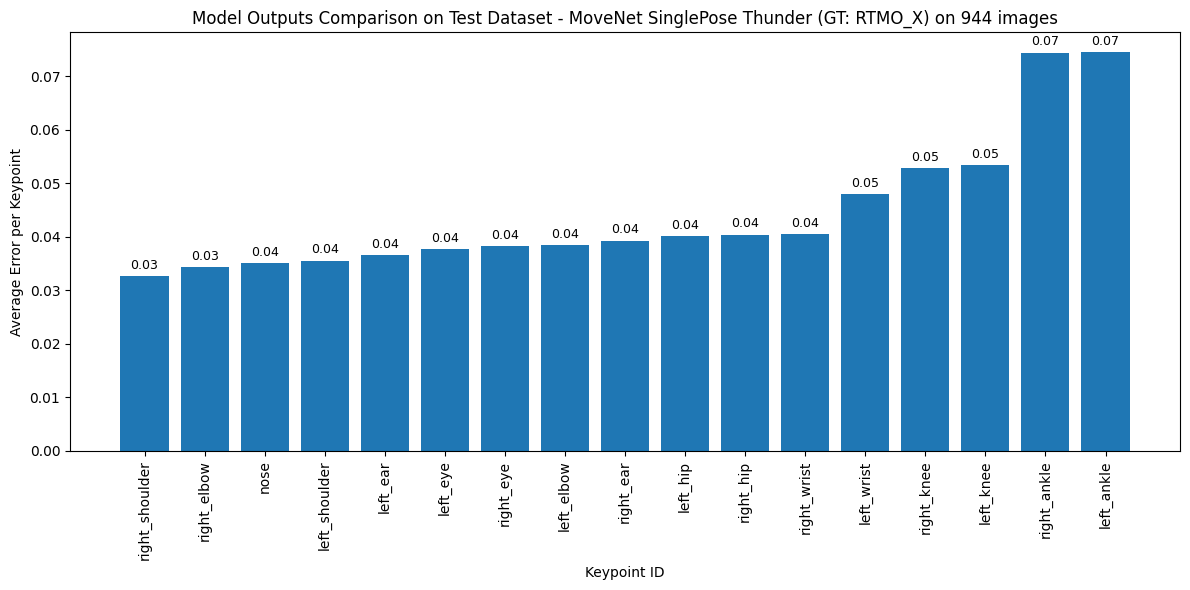

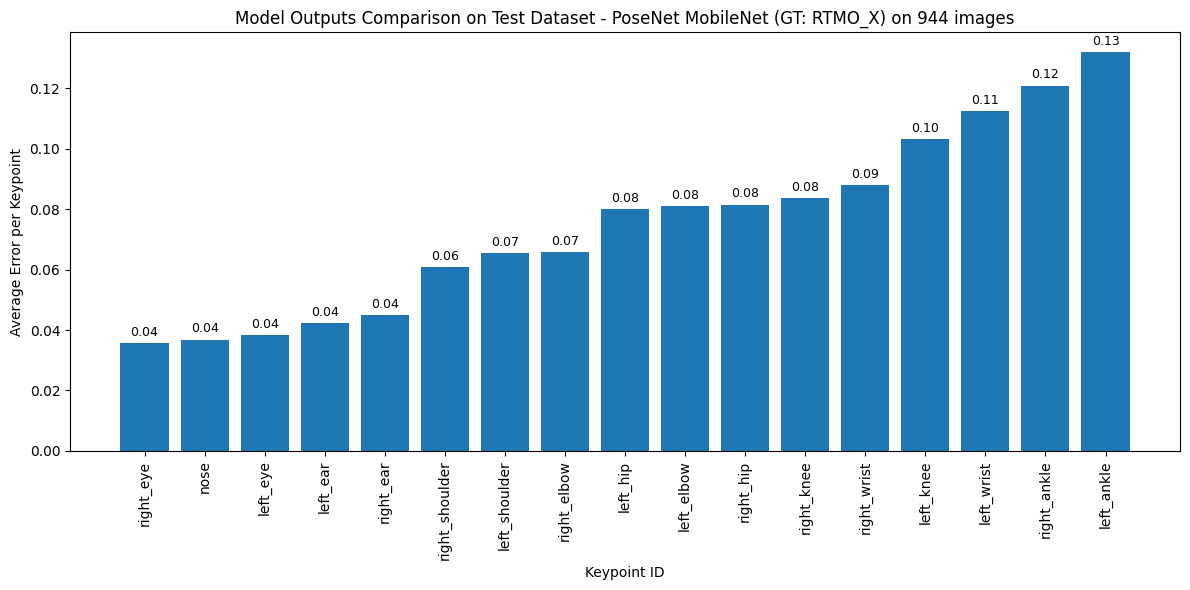

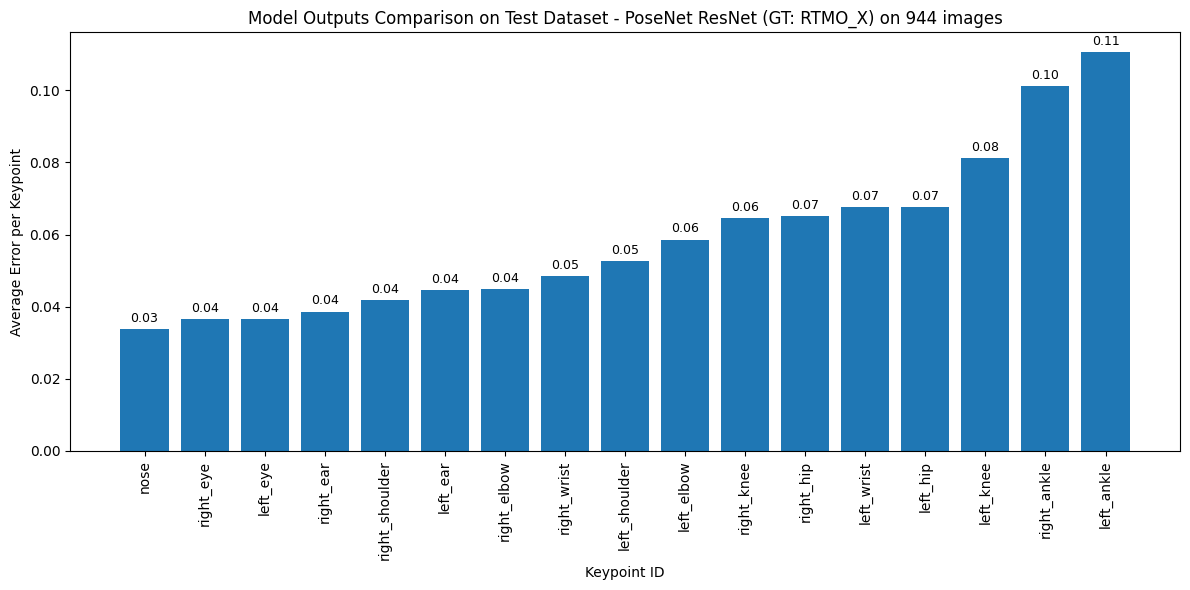

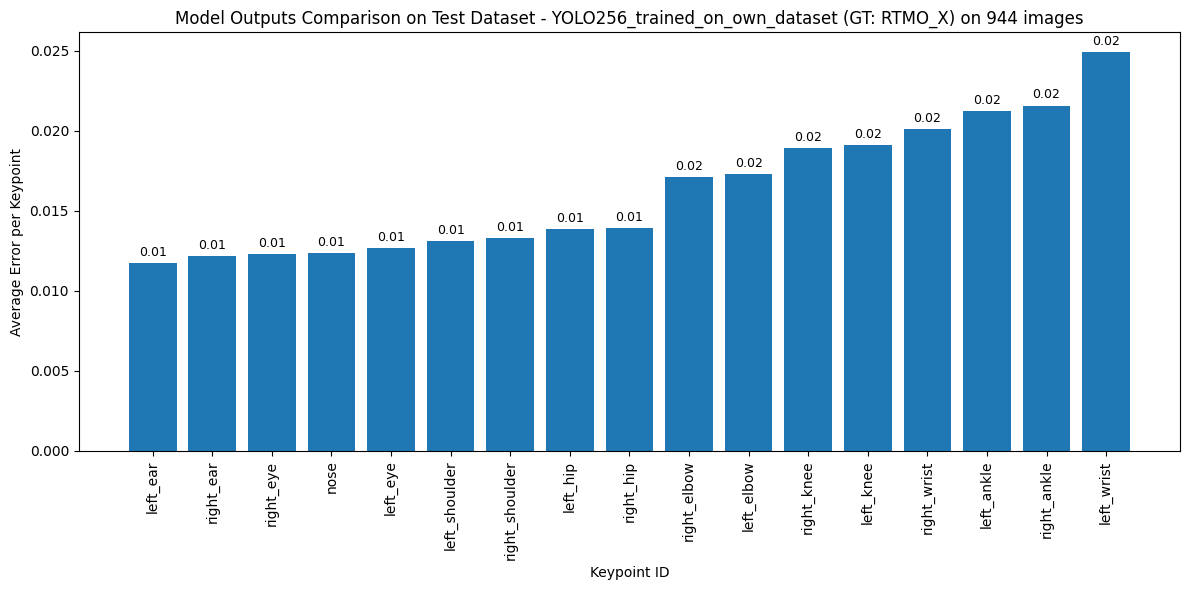

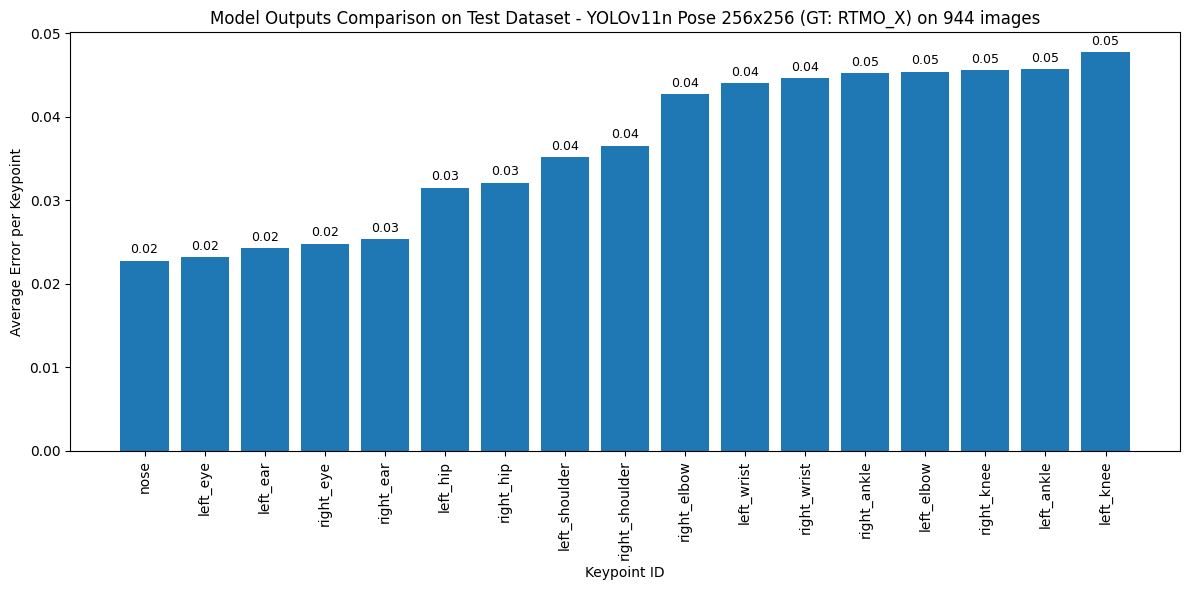

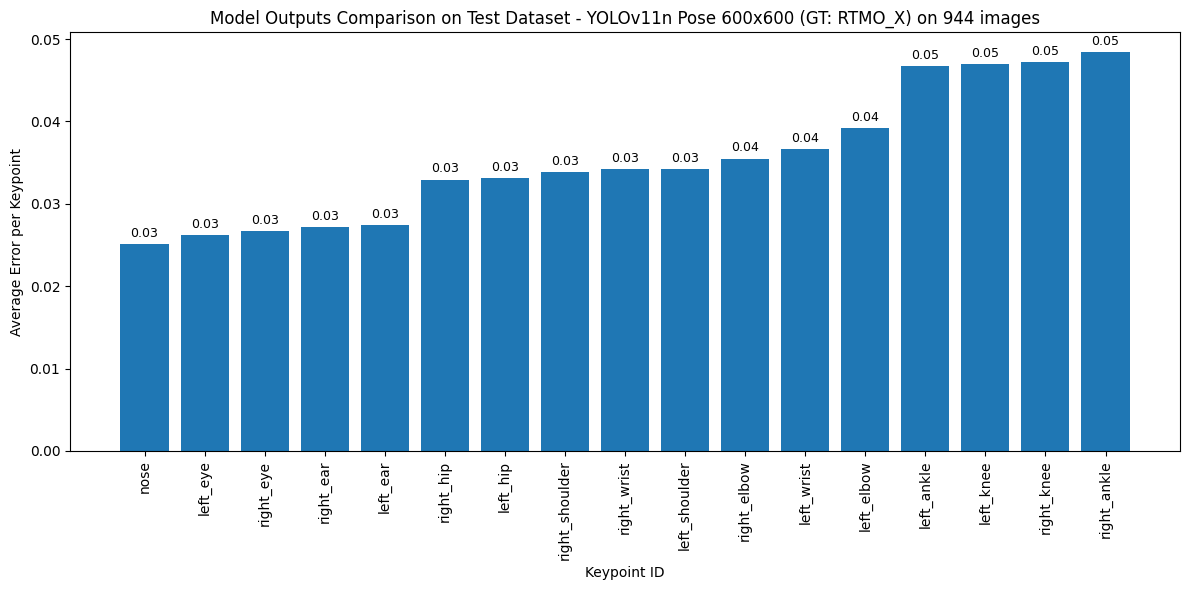

In [4]:
TITLE = "Model Outputs Comparison on Test Dataset"
FOLDER_NAME = "test-blindoff-dataset"
OUTPUTS_DIR_ROOT = Path(
    rf"D:\Magistrska\blindoff-magistrska\fitcode-frontend-next\public\exercise-cut-videos-to-images\{FOLDER_NAME}"
)
OUTPUTS_DIR_RESULTS = Path(f"{OUTPUTS_DIR_ROOT}/results")
GROUND_TRUTH_FILE_NAME = "RTMO_results.json"

# Find all .json files except ground truth
json_files = [
    f
    for f in os.listdir(OUTPUTS_DIR_RESULTS)
    if f.endswith(".json") and f != GROUND_TRUTH_FILE_NAME
]

# Read ground truth
with open(OUTPUTS_DIR_RESULTS / GROUND_TRUTH_FILE_NAME, "r", encoding="utf-8") as f:
    ground_truth = json.load(f)

# Read all model output files
model_outputs: List[dict] = []
for json_file in json_files:
    with open(OUTPUTS_DIR_RESULTS / json_file, "r", encoding="utf-8") as f:
        model_outputs.append(json.load(f))

# Build KEYPOINT_IDS automatically from ground truth (safer than hardcoding)
KEYPOINT_IDS = sorted(
    {kp["id"] for item in ground_truth["keypointsOnImages"] for kp in item["keypoints"]}
)

# Init model comparisons
model_comparisons = [
    {
        "model": out["model"],
        "keypoint_errors": {kp_id: 0.0 for kp_id in KEYPOINT_IDS},
    }
    for out in model_outputs
]


# Pre-index model outputs by file for fast lookup
# model_index[model_name][file] -> list of keypoints
images_len = 0
model_index: Dict[str, Dict[str, List[dict]]] = {}
for out in model_outputs:
    per_file = {}

    if images_len == 0:
        images_len = len(out.get("keypointsOnImages", []))
    elif images_len != len(out.get("keypointsOnImages", [])):
        raise ValueError(
            f"Model {out['model']} has different number of images ({len(out.get('keypointsOnImages', []))}) than previous models ({images_len})"
        )

    for item in out.get("keypointsOnImages", []):
        per_file[item["file"]] = item["keypoints"]
    model_index[out["model"]] = per_file

print(
    f"Comparing {len(model_outputs)} model outputs against ground truth from {ground_truth['model']} on {images_len} images."
)

# Iterate ground truth frames
for gt_item in ground_truth.get("keypointsOnImages", []):
    file = gt_item["file"]
    gt_keypoints = gt_item["keypoints"]

    # Compare each model vs this frame
    for comp in model_comparisons:
        model_name = comp["model"]
        model_keypoints = model_index.get(model_name, {}).get(file)

        if model_keypoints is None:
            print(f"No keypoints found for file {file} in model {model_name}")
            continue

        # Index model keypoints by id for O(1) access
        model_kp_by_id = {kp["id"]: kp for kp in model_keypoints}

        for gt_kp in gt_keypoints:
            kp_id = gt_kp["id"]
            model_kp = model_kp_by_id.get(kp_id)

            if model_kp is None:
                print(
                    f"No keypoint {kp_id} found for file {file} in model {model_name}"
                )
                continue

            if model_kp["pixelPosition"]["x"] == None or model_kp["pixelPosition"]["y"] == None:
                continue

            dx = gt_kp["pixelPosition"]["x"] - model_kp["pixelPosition"]["x"]
            dy = gt_kp["pixelPosition"]["y"] - model_kp["pixelPosition"]["y"]
            error = (dx * dx + dy * dy) ** 0.5

            comp["keypoint_errors"][kp_id] += error
            comp["count"] = comp.get("count", 0) + 1

# print(f"Model comparison results for {TITLE}:")
# for comp in model_comparisons:
#     print(f"Model: {comp['model']}")
#     errors_sum = sum(comp["keypoint_errors"].values())
#     print(f"  Total Keypoint Error: {errors_sum:.2f}")
#     for keypoint_id, error in comp["keypoint_errors"].items():
#         print(f"  Keypoint: {keypoint_id}, Total Error: {error:.2f}")
#     print()


# Plots

# ----------------- Output folders -----------------
plots_dir = OUTPUTS_DIR_ROOT / "plots"
per_model_dir = plots_dir / "per-model"
plots_dir.mkdir(parents=True, exist_ok=True)
per_model_dir.mkdir(parents=True, exist_ok=True)

# ---------- Prepare data ----------
# skip_models = ['YOLO256_trained_on_own_dataset']
skip_models = []

model_comparisons = [comp for comp in model_comparisons if comp["model"] not in skip_models]

models = [c["model"] for c in model_comparisons]


total_errors = [sum(c["keypoint_errors"].values()) for c in model_comparisons]

order = np.argsort(total_errors)  # best first
models_sorted = [models[i] for i in order]
total_errors_sorted = [total_errors[i] for i in order]

print(f"Plots saved to {plots_dir}")


# ---------- Plot 1: Total Keypoint Error for all models (with value labels) ----------
plt.figure(figsize=(12, 6))
bars = plt.bar(models_sorted, total_errors_sorted)
plt.title(
    f"{TITLE} — Total Keypoint Error vs Ground Truth ({ground_truth['model']}) on {images_len} images"
)
plt.ylabel("Total Keypoint Error (sum of Euclidean pixel errors)")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")


# Add numeric labels on top of each bar
for b in bars:
    h = b.get_height()
    plt.annotate(
        f"{h:.2f}",
        xy=(b.get_x() + b.get_width() / 2, h),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

total_plot_path = plots_dir / "total_keypoint_error.png"
plt.savefig(total_plot_path, dpi=200)
plt.show()

# ---------- Plot 2: Keypoint Error for all models averaged per image (with value labels) ----------
plt.figure(figsize=(12, 6))
avg_errors_sorted = [total_errors[i] / images_len for i in order]
bars = plt.bar(models_sorted, avg_errors_sorted)
plt.title(
    f"{TITLE} — Average Keypoint Error per Image vs Ground Truth ({ground_truth['model']}) on {images_len} images"
)
plt.ylabel("Average Keypoint Error per Image")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")

# Add numeric labels on top of each bar
for b in bars:
    h = b.get_height()
    plt.annotate(
        f"{h:.3f}",
        xy=(b.get_x() + b.get_width() / 2, h),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

total_plot_path = plots_dir / "avg_keypoint_error_per_image.png"
plt.savefig(total_plot_path, dpi=200)
plt.show()

# ---------- Plot 3: MPJPE (Mean per joint position error) ----------
plt.figure(figsize=(12, 6))
num_joints = len(KEYPOINT_IDS)
avg_per_joint_sorted = [total_errors[i] / (images_len * num_joints) for i in order]
bars = plt.bar(models_sorted, avg_per_joint_sorted)
plt.title(
    f"{TITLE} — MPJPE (Mean Per Joint Position Error) vs Ground Truth ({ground_truth['model']}) on {images_len} images"
)
plt.ylabel("MPJPE")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")


# Add numeric labels on top of each bar
for b in bars:
    h = b.get_height()
    plt.annotate(
        f"{h:.3f}",
        xy=(b.get_x() + b.get_width() / 2, h),
        xytext=(0, 3),  # 3 points vertical offset
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

total_plot_path = plots_dir / "mpjpe.png"
plt.savefig(total_plot_path, dpi=200)
plt.show()

# ---------- Plot 4: Keypoint errors per model (one plot per model, vertical labels) ----------
kp_ids = KEYPOINT_IDS


for comp in model_comparisons:
    model_name = comp["model"]

    if model_name in skip_models:
        print(f"Skipping per-keypoint plot for model {model_name}")
        continue

    items = sorted(comp["keypoint_errors"].items(), key=lambda kv: kv[1])
    items = [(kp_id, error / images_len) for kp_id, error in items]  # average by image count

    kp_ids_sorted = [str(k) for k, _ in items]
    kp_errors_sorted = [e for _, e in items]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(kp_ids_sorted, kp_errors_sorted)
    plt.title(
        f"{TITLE} - {model_name} (GT: {ground_truth['model']}) on {images_len} images"
    )
    plt.ylabel("Average Error per Keypoint")
    plt.xlabel("Keypoint ID")
    plt.xticks(rotation=90)

    # Add numeric labels on top of each bar
    for b in bars:
        h = b.get_height()
        plt.annotate(
            f"{h:.2f}",
            xy=(b.get_x() + b.get_width() / 2, h),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()

    fname = safe_filename(model_name) + ".png"
    out_path = per_model_dir / fname
    plt.savefig(out_path, dpi=200)
    plt.show()